ГЕНЕРАЦИЯ ДАТАСЕТА (ДЛЯ ПРОВЕРКИ РАБОТОСПОСОБНОСТИ)

,date,product_id,sales
0,2022-01-01,1,156.0
1,2022-01-02,1,186.0
2,2022-01-03,1,175.0
3,2022-01-04,1,172.0
4,2022-01-05,1,140.0
...,...,...,...
3645,2023-12-27,5,192.0
3646,2023-12-28,5,169.0
3647,2023-12-29,5,174.0
3648,2023-12-30,5,215.0


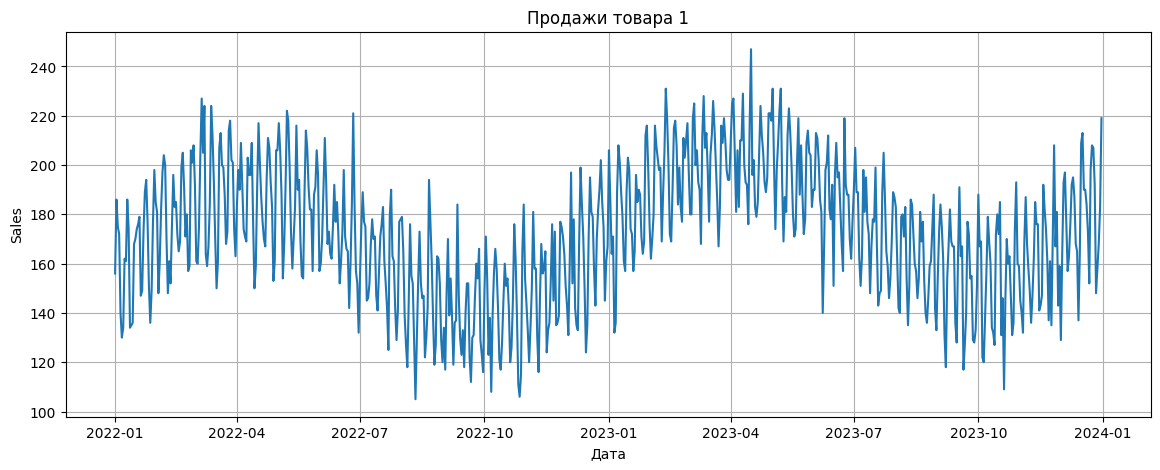

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n_days = 365 * 2          # 2 года
n_products = 5            # количество товаров
start_date = "2022-01-01"

dates = pd.date_range(start=start_date, periods=n_days, freq="D")

data = []

for product_id in range(1, n_products + 1):
    base = np.random.randint(50, 200)  # базовый спрос
    
    trend = np.linspace(0, np.random.randint(-20, 50), n_days)  # тренд
    
    weekly_seasonality = 20 * np.sin(2 * np.pi * np.arange(n_days) / 7)
    yearly_seasonality = 30 * np.sin(2 * np.pi * np.arange(n_days) / 365)
    
    noise = np.random.normal(0, 10, n_days)  # шум
    
    sales = base + trend + weekly_seasonality + yearly_seasonality + noise
    
    # эффект выходных (сб, вс)
    weekday = dates.weekday
    weekend_boost = np.where(weekday >= 5, 15, 0)
    sales = sales + weekend_boost
    
    # продажи не могут быть отрицательными
    sales = np.maximum(0, sales).round()
    
    for d, s in zip(dates, sales):
        data.append([d, product_id, s])

df = pd.DataFrame(data, columns=["date", "product_id", "sales"])
display(df)

sample_product = 1

df_sample = df[df["product_id"] == sample_product]

plt.figure(figsize=(14, 5))
plt.plot(df_sample["date"], df_sample["sales"])
plt.title(f"Продажи товара {sample_product}")
plt.xlabel("Дата")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

df.to_csv("sales_data.csv", index=False)

ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ: РАЗДЕЛЕНИЕ НА ВЫБОРКИ TRAIN/TEST

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

train = df[df["date"] < "2023-07-01"]
test = df[df["date"] >= "2023-07-01"]

print(f"Train data: {train.shape}\nTest data: {test.shape}")

Train data: (2730, 3)
Test data: (920, 3)


ФУНКЦИЯ ДЛЯ SLIDING WINDOW + ГЕНЕРАЦИЯ ОКОН

In [13]:
def create_sliding_windows(data, input_days=14, output_days=7):
    windows = []
    for product_id in range(1, n_products + 1):
        product_data = data[data["product_id"] == product_id].reset_index(drop=True)
        
        for i in range(len(product_data) - input_days - output_days):
            x = product_data["sales"].iloc[i:i+input_days].values  # последние 14 дней
            y = product_data["sales"].iloc[i+input_days:i+input_days+output_days].values  # прогноз на 7 дней
            windows.append((x, y))
    
    return windows

train_windows = create_sliding_windows(train)
test_windows = create_sliding_windows(test)

print(f"Обучающих окон: {len(train_windows)}, Тестовых окон: {len(test_windows)}")

Обучающих окон: 2625, Тестовых окон: 815


МАСШТАБИРОВАНИЕ ДАННЫХ (MINMAXSCALER)

In [14]:
scaler = MinMaxScaler()

train_sales = [window[0] for window in train_windows]  # только входы
test_sales = [window[0] for window in test_windows]    # только входы

train_sales = scaler.fit_transform(train_sales)
test_sales = scaler.transform(test_sales)

print(f"Нормализованные данные:\n   Train: {train_sales[0][:5]}\n   Test: {test_sales[0][:5]}")

Нормализованные данные:
   Train: [0.55513308 0.66920152 0.62737643 0.61596958 0.49429658]
   Test: [0.68441065 0.74904943 0.68060837 0.68060837 0.57794677]


МОДЕЛЬКА
1. ЛИНЕЙНАЯ РЕГРЕССИЯ - BASELINE